## Matriz 9 box para avaliar a performance dos colaboradores em relação ao salário e à quantidade de colaboradores

# 9 BOX - Performance x Potencial

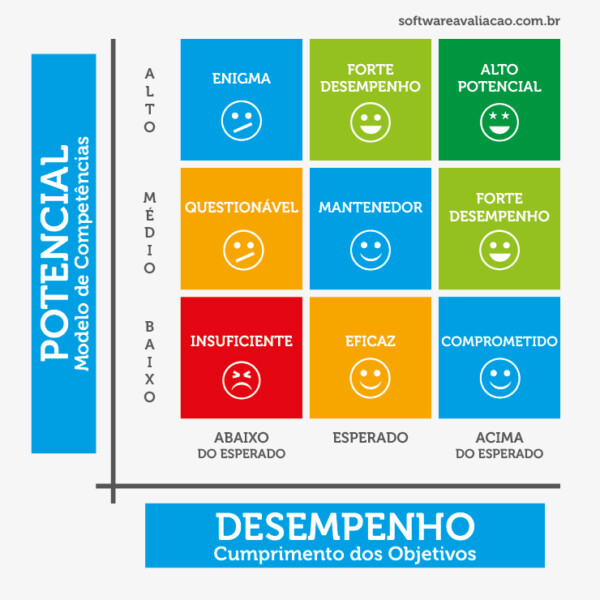

Indivíduos identificados como trabalhadores de alto potencial podem estar mais preparados para assumir novas posições dentro da empresa.

# Performance x potencial
Performance = Nota de avaliação
Potencial =  "reconhecimento de performance", "número de treinamentos" e "tempo de casa".



In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
### Para baixar a base:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

# print("Path to dataset files:", path)

In [8]:
bd_rh = pd.read_csv("https://raw.githubusercontent.com/fabiocuryfcp/dataset/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv")
bd_rh.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [9]:

bd_rh = bd_rh[bd_rh['Attrition'] == 'No'] ## Podemos analisar os que sairam depois, mas vamos focar nos que ficaram por enquanto


bd_rh = bd_rh[['EmployeeCount', #'EmployeeNumber','Gender', 'JobRole', 'Department','MaritalStatus', 'BusinessTravel','OverTime', ##### Demográfico 
       
       'DailyRate', 'MonthlyRate', #Avaliação recente
       'PerformanceRating', # Avaliação performance

       'EnvironmentSatisfaction', 'RelationshipSatisfaction', # Satisfação com o ambiente de trabalho
       'JobInvolvement','JobSatisfaction', # satisfação com o escopo de trabalho
       'WorkLifeBalance', # satisfação com a jornada de trabalho
       
       'MonthlyIncome','PercentSalaryHike', #Remuneração
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager' # tempo na empresa
       ]]



In [10]:
### Criar indicadores

# Performance com base em avaliação diaria, mensal e nota de performance
#DailyRate - 5%
bd_rh['DailyRate'] = bd_rh['DailyRate']/bd_rh['DailyRate'].max()
#MonthlyRate - 10%
bd_rh['MonthlyRate'] = bd_rh['MonthlyRate']/bd_rh['MonthlyRate'].max()
#PerformanceRating - 85%
bd_rh['PerformanceRating'] = bd_rh['PerformanceRating']/5

## 1.Performance GERAL
bd_rh["Performance_n"] = bd_rh['DailyRate']*0.05 + bd_rh['MonthlyRate']*0.1 + bd_rh['PerformanceRating']*0.85
bd_rh["Performance_n"] = (bd_rh["Performance_n"] * bd_rh["PercentSalaryHike"]/100).round(2)
##########################################################

## 2.Satisfação geral
bd_rh['Satisfação'] = bd_rh[['EnvironmentSatisfaction', 'RelationshipSatisfaction', # Satisfação com o ambiente de trabalho
       'JobInvolvement','JobSatisfaction', # satisfação com o escopo de trabalho
       'WorkLifeBalance']].mean(axis=1)
##########################################################

## 3. Potencial com base no tempo de casa, tempo no cargo, tempo desde a última promoção e tempo com o gerente atual
for col in ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']:
    bd_rh[col] = np.where(bd_rh[col] <= bd_rh[col].mean(), 1, 0)

bd_rh["Potential_Time"] = (bd_rh["YearsAtCompany"] + bd_rh["YearsInCurrentRole"] + bd_rh["YearsSinceLastPromotion"] + bd_rh["YearsWithCurrManager"])/4
##########################################################

##4. Potencial tempo x Satisfação
bd_rh['Potential_Satisfação'] = bd_rh['Potential_Time']*bd_rh['Satisfação']



In [11]:
####################################################################################
#### (9 BOX)    
ninebox = bd_rh[['Potential_Satisfação',"Performance_n",
                   "MonthlyIncome",'EmployeeCount']].copy()

# Rótulos da matriz 9Box
labels = ['Improve Opportunity', 'High Value', 'Top Tier']

# (9Box - Performance)
#Performance
bins_perf = [
    # bd_9box['Performance'].quantile(0.00),  # Min
    ninebox['Performance_n'].quantile(0.01),
    ninebox['Performance_n'].quantile(0.67),
    ninebox['Performance_n'].quantile(0.85),
    float('inf')  # acima de 85% do percentil
]

ninebox['Performance'] = pd.cut(ninebox['Performance_n'], bins=bins_perf, labels=labels)

# (9Box - Comportamental)
# Potencial x Satisfação
bins_pot = [
    # bd_9box['Potential_Satisfação'].quantile(0.00),  # Min
    ninebox['Potential_Satisfação'].quantile(0.01),
    ninebox['Potential_Satisfação'].quantile(0.70),
    ninebox['Potential_Satisfação'].quantile(0.85),
    float('inf')  # acima de 85% do percentil
]

ninebox['Potencial'] = pd.cut(ninebox['Potential_Satisfação'], bins=bins_pot, labels=labels)


In [12]:
ninebox = ninebox[["Potencial",'Potential_Satisfação',
                   "Performance", 'Performance_n',
                   "MonthlyIncome",'EmployeeCount']].copy()


# ninebox = ninebox[(ninebox.Potential_label!='NO_PROFILE') & (ninebox.Perf_label!='NO_PROFILE')] ## Removido ao não considerar o percentil 0)

ninebox['fator'] = ninebox.Potential_Satisfação*ninebox.Performance_n

conditions = [
    (ninebox['Potencial'] == 'Top Tier') & (ninebox['Performance'] == 'Top Tier'),  ### 'Star'// 'Alto Potencial'
    (ninebox['Potencial'] == 'High Value') & (ninebox['Performance'] == 'Top Tier'), ### 'Performance'// 'Forte Desempenho'
    (ninebox['Potencial'] == 'Top Tier') & (ninebox['Performance'] == 'High Value'), ### 'People Leader'// 'Forte Desempenho'

    (ninebox['Potencial'] == 'Improve Opportunity') & (ninebox['Performance'] == 'Top Tier'), ### 'Culture Danger'// 'Comprometido'
    (ninebox['Potencial'] == 'High Value') & (ninebox['Performance'] == 'High Value'), ### 'Average' // 'Mantenedor'
    (ninebox['Potencial'] == 'Top Tier') & (ninebox['Performance'] == 'Improve Opportunity'), ### 'PDI_Performance' // 'Enigma'

    (ninebox['Potencial'] == 'Improve Opportunity') & (ninebox['Performance'] == 'High Value'), ### 'Dismiss(behavior)'// 'Eficaz'
    (ninebox['Potencial'] == 'High Value') & (ninebox['Performance'] == 'Improve Opportunity'), ### 'Average_LowPerformance'// 'Questionável'
    (ninebox['Potencial'] == 'Improve Opportunity') & (ninebox['Performance'] == 'Improve Opportunity'), ### 'Dismiss(Performance)// 'Insuficiente'
    # (ninebox['Potencial'] == 'NO_PROFILE') & (ninebox['Performance'] == 'NO_PROFILE'), ### 'Just_Hired'    
]

# choices = [
#     'Star', 'Performance', 'Culture Danger',
#     'People Leader', 'Average', 'Dismiss(behavior)',
#     'PDI_Performance', 'Average_LowPerformance', 'Dismiss(Performance)'
# ]
# ninebox['class9b'] = np.select(conditions, choices, default= "Just_Hired")


choices = [
    'Alto Potencial', 'Forte Desempenho', 'Forte Desempenho',
    'Comprometido', 'Mantenedor', 'Enigma',
    'Eficaz','Questionável', 'Insuficiente'
]
ninebox['class9b'] = np.select(conditions, choices, default= "recém-contratado")



## Aqui tenho a planilha completa
# ninebox

In [13]:
dados_leitura = ninebox[['Performance','Potencial','class9b']].dropna().drop_duplicates().sort_index(ascending=False)

In [14]:
# Função que prepara os dados para o gráfico 9Box
def preparar_9box(df, axis_x='Performance', axis_y='Potencial', col_tamanho='EmployeeCount', cor = 'class9b'):
        
    # Limpeza: Remover NaN e Infinitos
    df_9box = df[[axis_x,axis_y,col_tamanho,]].dropna(axis=0)
    
    # Agrupar os dados, caso necessário
    df_9box_grouped = df_9box.groupby([axis_x, axis_y], as_index=False).sum()  # Agrupa por eixo X e Y e soma o tamanho
    
    # Proporções para o gráfico
    total = df_9box_grouped[col_tamanho].sum()
    df_9box_grouped[col_tamanho] = (df_9box_grouped[col_tamanho] / total) * 100

    df_9box_grouped['hue']= df_9box_grouped[axis_x].astype(str) + ' - ' + df_9box_grouped[axis_y].astype(str)
    
    return df_9box_grouped


###### Gráfico 9Box

# Função simples para gerar o gráfico 9Box
def grafico_9box(df, axis_x='Performance', axis_y='Potencial', col_tamanho='EmployeeCount'):
    
    plt.figure(figsize=(10, 10))
    
    # Gerar o gráfico com relplot
    relp = sns.relplot(data=df, x=axis_x, y=axis_y, hue='hue', size=col_tamanho, palette="tab10", 
                       sizes=(1000, 6000), legend=False, aspect=1.5)
    
    # Configurar título e rótulos dos eixos
    relp.set_axis_labels(axis_x, axis_y)
    plt.title(f'9BOX - Fator (% {col_tamanho})', fontsize=16)
    
    # Inverter o eixo Y
    plt.gca().invert_yaxis()
    
    # Adicionar as anotações para cada ponto
    # Add annotations manually
    for line in range(0, df.shape[0]):
        plt.text(df[axis_x][line], df[axis_y][line], '{:.1f}'.format(df[col_tamanho][line]),
                 horizontalalignment='center', verticalalignment='center', color='black')
    
    # Mostrar o gráfico
    plt.tight_layout()
    plt.show()


In [15]:
df1 = preparar_9box(df=ninebox, axis_x='Performance', axis_y='Potencial', col_tamanho='EmployeeCount')
df2 = preparar_9box(df=ninebox, axis_x='Performance', axis_y='Potencial', col_tamanho='MonthlyIncome')

In [16]:
### MEdia Salarial
df3= ninebox[['Performance','Potencial','MonthlyIncome','EmployeeCount']].dropna()

    # Agrupar os dados, caso necessário
df3 = df3.groupby(['Performance','Potencial'], as_index=False).sum()  # Agrupa por eixo X e Y e soma o tamanho
    
    # Proporções para o gráfico
df3['sal Medio'] = (df3['MonthlyIncome'] / df3['EmployeeCount'])

df3['hue']= df3['Performance'].astype(str) + ' - ' + df3['Potencial'].astype(str)
    
df3.drop(columns=['EmployeeCount','MonthlyIncome'], inplace=True)
df3

,Performance,Potencial,sal Medio,hue
0,Improve Opportunity,Improve Opportunity,6800.970721,Improve Opportunity - Improve Opportunity
1,Improve Opportunity,High Value,5033.879195,Improve Opportunity - High Value
2,Improve Opportunity,Top Tier,5649.525253,Improve Opportunity - Top Tier
3,High Value,Improve Opportunity,6650.030769,High Value - Improve Opportunity
4,High Value,High Value,4997.520000,High Value - High Value
5,High Value,Top Tier,5556.315789,High Value - Top Tier
6,Top Tier,Improve Opportunity,6472.968085,Top Tier - Improve Opportunity
7,Top Tier,High Value,5766.968750,Top Tier - High Value
8,Top Tier,Top Tier,6496.062500,Top Tier - Top Tier


,Performance,Potencial,class9b
87,Top Tier,Top Tier,Alto Potencial
54,High Value,High Value,Mantenedor
49,High Value,Top Tier,Forte Desempenho
39,High Value,Improve Opportunity,Eficaz
20,Improve Opportunity,High Value,Questionável
17,Improve Opportunity,Top Tier,Enigma
7,Top Tier,High Value,Forte Desempenho
3,Improve Opportunity,Improve Opportunity,Insuficiente
1,Top Tier,Improve Opportunity,Comprometido


<Figure size 720x720 with 0 Axes>

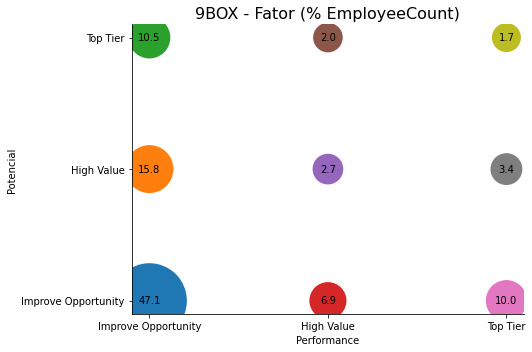

<Figure size 720x720 with 0 Axes>

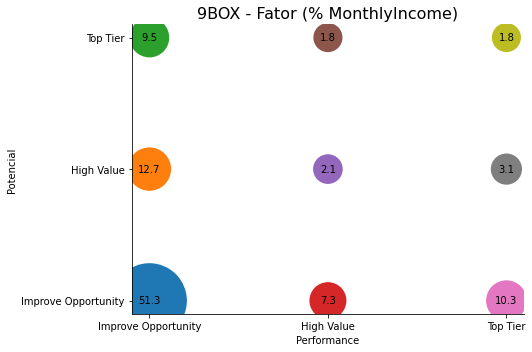

<Figure size 720x720 with 0 Axes>

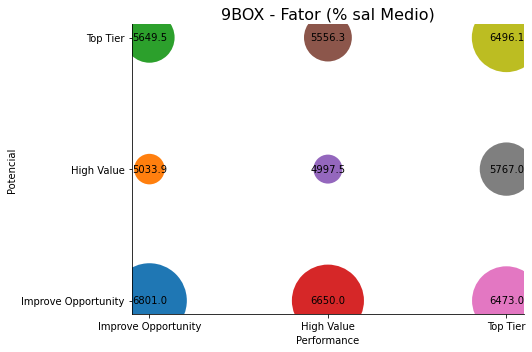

In [17]:
display(dados_leitura)

grafico_9box(df=df1, col_tamanho='EmployeeCount')

grafico_9box(df=df2, col_tamanho='MonthlyIncome')

grafico_9box(df=df3, col_tamanho='sal Medio')


Nas análises o quadrante Insuficiente apresenta muito destaque, mostrando que há uma necessidade de ajuste em relação à performance dos colaboradores. Nas matrizes que cruzam as informações de performance com a quantidade de colaboradores e o custo (em salário mensal) dos mesmos, quase metade foi classificada como insuficiente.

As 3 categorias mais interessantes (Alto Potencial, Forte Desempenho e Mantendor), não somam mais de 10% nem em quantidade, nem em valor.

E agora?

Agora a cia precisa repensar algumas coisas, 

Hipótese 1: Contratações, buscar novos colaboradores que apresentem maior potencial e melhor desempenho (Contrate devagar e demita rápido)

Hipótese 2: Revisão de PDI para incentivar o desenvolvimento interno, aproximadamente 70% dos colaboradores e do valor pago em salários não foi classificado como TopTier

Hipótese 3: rever a estrutura de remuneração, de maneira que os top performers tenham mais peso na remuneração, note que a maior média salarial está nos colaboradores com desempenho insuficiente, seguido pelos colaboradores eficazes, só então aparecem os colaboradores de alto potencial
(considerar de maneira igualitária colaboradores com performances muito diferentes pode ocasionar perda de talentos e retenção de colaboradores que não são tão valiosos assim)